# Chapter 26 Lab — Experiments, Observation, and Causality (Python)

Causal structure is one of the few things in statistics you can *see* directly, because in simulation you know the ground truth. In this lab you will:

1. **Recreate the hormone replacement therapy (HRT) story** — the same simulated population analyzed observationally vs. as a randomized trial
2. **Simulate a confounder** and show that covariate adjustment removes the bias, across hundreds of replications
3. **Simulate a collider** and show that the same adjustment *creates* bias — and that selecting observations on a collider (as in post-hoc trial exclusion) does too
4. **Preview mediation analysis** on a simulated task → brain → behavior chain, with a bootstrap test of the indirect effect

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `pandas`, `matplotlib`, and `statsmodels`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch26-experiments-observation-and-causality.md).

*Simulation design adapted from CANlab teaching code (github.com/canlab; FMRI_simulations `covariates_in_regression.m`) and the CANlab Mediation Toolbox tutorials.*

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

rng = np.random.default_rng(26)

def ols_slope(y, X):
    """Return (estimate, t-value) for the first column of X, with intercept added."""
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c) for c in np.atleast_2d(X.T)])
    fit = sm.OLS(y, X).fit()
    return fit.params[1], fit.tvalues[1]

## 1. Observation vs. experiment: the HRT story in numbers

In the 1980s–90s, large observational studies found that women taking hormone replacement therapy (HRT) had substantially *lower* rates of heart disease — but a large randomized trial later showed HRT *increases* heart disease. The culprit was **healthy-user bias**: healthier people were more likely to elect HRT, and being healthy independently protects against heart disease.

We simulate one population in which the ground truth is that treatment is **harmful** (+0.3 on a disease-risk score), then analyze it two ways:

- **Observational study:** people *choose* treatment, and healthier people (higher latent health $H$) choose it more often
- **Randomized trial:** a coin flip assigns treatment, severing the link between health and treatment

In [2]:
n = 5000
b_true = 0.3                                   # TRUE causal effect of treatment: HARMFUL

H = rng.standard_normal(n)                     # latent "general health" (unmeasured)

# --- Observational study: healthier people opt in to treatment ---
p_take = 1 / (1 + np.exp(-1.5 * H))            # P(taking HRT) rises with health
T_obs = (rng.random(n) < p_take).astype(float)
Y_obs = b_true * T_obs - 1.0 * H + rng.standard_normal(n)   # health lowers disease risk

# --- Randomized trial: coin-flip assignment, same causal model ---
T_rct = (rng.random(n) < 0.5).astype(float)
Y_rct = b_true * T_rct - 1.0 * H + rng.standard_normal(n)

obs_effect = Y_obs[T_obs == 1].mean() - Y_obs[T_obs == 0].mean()
rct_effect = Y_rct[T_rct == 1].mean() - Y_rct[T_rct == 0].mean()

print(f"True causal effect of treatment on disease risk: +{b_true:.2f} (harmful)")
print(f"Observational estimate (self-selected treatment): {obs_effect:+.2f}  <-- looks protective!")
print(f"Randomized trial estimate:                        {rct_effect:+.2f}  <-- correct")

True causal effect of treatment on disease risk: +0.30 (harmful)
Observational estimate (self-selected treatment): -0.73  <-- looks protective!
Randomized trial estimate:                        +0.26  <-- correct


The observational study gets the **sign wrong**: treatment looks protective because the treated group is healthier to begin with. Randomization makes treatment independent of health (and of every other confounder, measured or not), so the simple group difference recovers the true harmful effect.

Note what randomization did *not* require: we never measured $H$. That is the magic — it handles the confounders you did not think of.

## 2. A confounder: adjusting for it removes bias

Now the continuous version, matching the chapter's causal diagram. The confounder $C$ drives both the exposure $X$ and the outcome $Y$:

$$X = 0.7\,C + u, \qquad Y = 0.4\,X - 1.2\,C + e$$

The true causal effect of $X$ on $Y$ is $+0.4$. Regressing $Y$ on $X$ alone yields, in expectation,

$$\mathbb{E}[\hat{\beta}_X] = b + ac\,\frac{\mathrm{Var}(C)}{\mathrm{Var}(X)} = 0.4 + \frac{(0.7)(-1.2)}{0.7^2 + 1} \approx -0.16$$

— biased right past zero to the wrong sign. Adjusting for $C$ should recover $+0.4$. We repeat the experiment 500 times to see the whole sampling distribution, not just one lucky draw.

In [3]:
n, n_reps = 500, 500
a, b, c = 0.7, 0.4, -1.2                       # C->X, X->Y (true), C->Y paths

est = np.zeros((n_reps, 2))                    # columns: naive, adjusted
for i in range(n_reps):
    C = rng.standard_normal(n)
    X = a * C + rng.standard_normal(n)
    Y = b * X + c * C + rng.standard_normal(n)
    est[i, 0], _ = ols_slope(Y, np.column_stack([X]))       # naive: omit C
    est[i, 1], _ = ols_slope(Y, np.column_stack([X, C]))    # adjusted for C

expected_naive = b + a * c / (a**2 + 1)
print(f"True effect b = {b:.2f}")
print(f"Naive    (omit C):   mean estimate = {est[:, 0].mean():+.3f}"
      f"   (theory: {expected_naive:+.3f})")
print(f"Adjusted (include C): mean estimate = {est[:, 1].mean():+.3f}")

True effect b = 0.40
Naive    (omit C):   mean estimate = -0.165   (theory: -0.164)
Adjusted (include C): mean estimate = +0.401


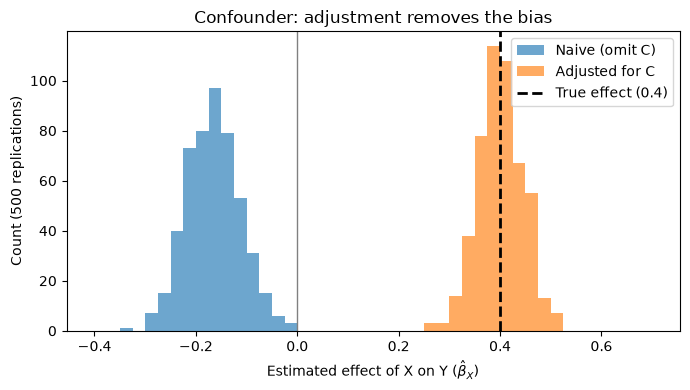

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-0.4, 0.7, 45)
ax.hist(est[:, 0], bins=bins, alpha=0.65, label="Naive (omit C)")
ax.hist(est[:, 1], bins=bins, alpha=0.65, label="Adjusted for C")
ax.axvline(b, color="k", ls="--", lw=2, label=f"True effect ({b})")
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel(r"Estimated effect of X on Y ($\hat{\beta}_X$)")
ax.set_ylabel("Count (500 replications)")
ax.set_title("Confounder: adjustment removes the bias")
ax.legend()
plt.tight_layout()
plt.show()

Every naive replication is biased — the entire histogram sits on the wrong side of zero — while the adjusted estimates cluster tightly around the truth. This is the classic case where "controlling for" a covariate is exactly right: the covariate is a **common cause** of exposure and outcome.

In fMRI, this is the logic behind motion regressors, physiological noise covariates, and matching groups on age and sex: variables that plausibly influence both the IV side (or group membership) and the measured signal.

## 3. A collider: adjusting for it *creates* bias

Now flip the arrows. $X$ and $Y$ are **truly unrelated**, but both feed into a downstream composite $S$:

$$S = X + Y + \text{noise}$$

Think of $S$ as an "inclusion score" — a summary of task performance and data quality, both of which are affected by the participant's attention (which also drives brain measures) and by the outcome being studied. $S$ is a **collider**: arrows collide into it. Conditioning on a collider opens a spurious path between its causes.

In [5]:
est_col = np.zeros((n_reps, 2))                # columns: naive, collider-adjusted
for i in range(n_reps):
    X = rng.standard_normal(n)
    Y = rng.standard_normal(n)                 # true effect of X on Y = 0
    S = X + Y + rng.standard_normal(n)         # collider: caused by BOTH X and Y
    est_col[i, 0], _ = ols_slope(Y, np.column_stack([X]))      # correct model
    est_col[i, 1], _ = ols_slope(Y, np.column_stack([X, S]))   # "controls for" S

print("True effect of X on Y = 0")
print(f"Naive (no adjustment):        mean estimate = {est_col[:, 0].mean():+.3f}")
print(f"Adjusted for collider S:      mean estimate = {est_col[:, 1].mean():+.3f}  <-- spurious!")

True effect of X on Y = 0
Naive (no adjustment):        mean estimate = -0.004
Adjusted for collider S:      mean estimate = -0.502  <-- spurious!


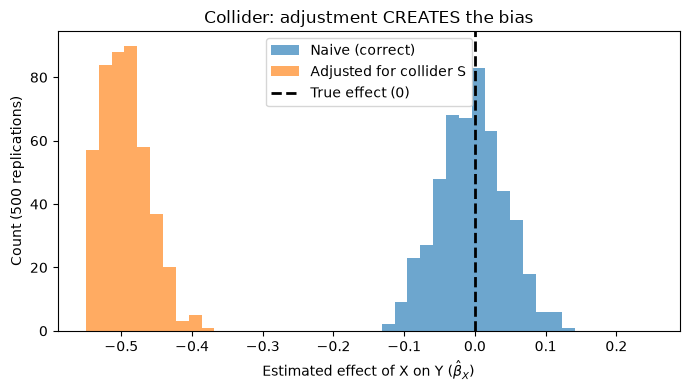

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-0.55, 0.25, 45)
ax.hist(est_col[:, 0], bins=bins, alpha=0.65, label="Naive (correct)")
ax.hist(est_col[:, 1], bins=bins, alpha=0.65, label="Adjusted for collider S")
ax.axvline(0, color="k", ls="--", lw=2, label="True effect (0)")
ax.set_xlabel(r"Estimated effect of X on Y ($\hat{\beta}_X$)")
ax.set_ylabel("Count (500 replications)")
ax.set_title("Collider: adjustment CREATES the bias")
ax.legend()
plt.tight_layout()
plt.show()

The unadjusted analysis is centered on the truth (zero); the "carefully controlled" analysis is biased to about $-0.5$ in every single replication, and with $n = 500$ the spurious effect will usually be highly significant. Adding covariates is not automatically conservative.

**Selection is conditioning too.** You do not need to enter the collider in the model — analyzing only observations with high $S$ (e.g., keeping only "clean, high-performance" trials or participants) conditions on it just the same:

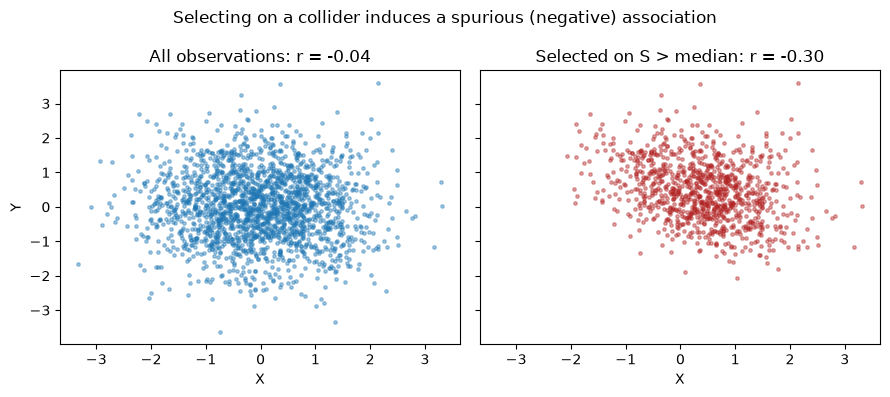

In [7]:
X = rng.standard_normal(2000)
Y = rng.standard_normal(2000)                  # truly unrelated
S = X + Y + rng.standard_normal(2000)
keep = S > np.median(S)                        # post-hoc selection on the collider

r_all = np.corrcoef(X, Y)[0, 1]
r_sel = np.corrcoef(X[keep], Y[keep])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
axes[0].scatter(X, Y, s=6, alpha=0.4)
axes[0].set_title(f"All observations: r = {r_all:+.2f}")
axes[1].scatter(X[keep], Y[keep], s=6, alpha=0.4, color="firebrick")
axes[1].set_title(f'Selected on S > median: r = {r_sel:+.2f}')
for ax in axes:
    ax.set_xlabel("X")
axes[0].set_ylabel("Y")
fig.suptitle("Selecting on a collider induces a spurious (negative) association")
plt.tight_layout()
plt.show()

Among the selected observations, $X$ and $Y$ are negatively correlated even though they are causally unrelated: to make it past the threshold, an observation low on $X$ must be high on $Y$, and vice versa. This is why post-hoc exclusion of trials or subjects based on performance, missing behavioral data, or head motion needs scrutiny — if the exclusion variable is downstream of both your IV and your DV, the "cleaned" dataset is a biased one.

**The rule of thumb:** adjust for common *causes* (confounders); never adjust for common *effects* (colliders). The regression cannot tell the difference — only your causal model can.

## 4. Mediation preview: task → brain → behavior

In a typical task fMRI study the task $X$ is randomized, but brain activity $M$ and behavior $Y$ are only *observed*. The brain sits in the middle of the causal chain — a **mediator**:

$$M = a\,X + e_M, \qquad Y = b\,M + c'\,X + e_Y$$

- $a$: effect of the task on brain activity (experimentally secured by randomization)
- $b$: relationship between brain activity and behavior, controlling for the task
- $c'$: *direct* effect of the task on behavior, bypassing this brain measure
- $c = c' + ab$: the *total* effect; $ab$ is the **indirect (mediated) effect**

We simulate a painful-heat experiment: stimulus intensity $X$ (randomized, so no confounding of the $a$-path), a brain response $M$, and reported pain $Y$.

In [8]:
n = 200
a_true, b_true, cprime_true = 0.6, 0.5, 0.2

X = rng.permutation(np.repeat([0., 1.], n // 2))     # randomized: low/high intensity
M = a_true * X + rng.standard_normal(n)              # brain response (observed)
Y = b_true * M + cprime_true * X + rng.standard_normal(n)   # reported pain

a_hat,  _ = ols_slope(M, np.column_stack([X]))                 # a-path:  M ~ X
c_hat,  _ = ols_slope(Y, np.column_stack([X]))                 # total:   Y ~ X
XM = np.column_stack([np.ones(n), X, M])
fit_y = sm.OLS(Y, XM).fit()
cprime_hat, b_hat = fit_y.params[1], fit_y.params[2]           # Y ~ X + M

print(f"a  (task -> brain):        {a_hat:+.3f}   (true {a_true})")
print(f"b  (brain -> behavior|X):  {b_hat:+.3f}   (true {b_true})")
print(f"c  (total effect):         {c_hat:+.3f}   (true {cprime_true + a_true * b_true:.2f})")
print(f"c' (direct effect):        {cprime_hat:+.3f}   (true {cprime_true})")
print(f"a*b (indirect effect):     {a_hat * b_hat:+.3f}   (true {a_true * b_true:.2f})")
print(f"check: c - c' = {c_hat - cprime_hat:+.3f}  equals  a*b = {a_hat * b_hat:+.3f}")

a  (task -> brain):        +0.481   (true 0.6)
b  (brain -> behavior|X):  +0.412   (true 0.5)
c  (total effect):         +0.523   (true 0.50)
c' (direct effect):        +0.325   (true 0.2)
a*b (indirect effect):     +0.198   (true 0.30)
check: c - c' = +0.198  equals  a*b = +0.198


The indirect effect $ab$ equals $c - c'$ (exactly, in linear models): the portion of the task's total effect on behavior that is transmitted through this brain measure. Because $ab$ is a *product* of estimates, its sampling distribution is skewed, so the standard test uses the **bootstrap**: resample participants with replacement, recompute $ab$ each time, and read the confidence interval off the distribution.

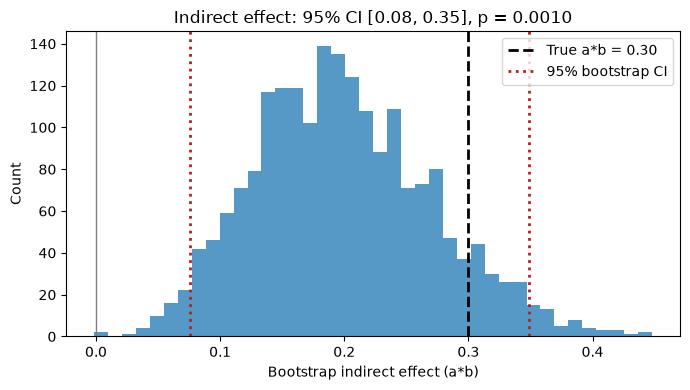

In [9]:
n_boot = 2000
ab_boot = np.zeros(n_boot)
for i in range(n_boot):
    idx = rng.integers(0, n, n)                      # resample participants
    Xb, Mb, Yb = X[idx], M[idx], Y[idx]
    a_b, _ = ols_slope(Mb, np.column_stack([Xb]))
    fit_b = sm.OLS(Yb, np.column_stack([np.ones(n), Xb, Mb])).fit()
    ab_boot[i] = a_b * fit_b.params[2]

ci = np.percentile(ab_boot, [2.5, 97.5])
p_boot = 2 * min((ab_boot <= 0).mean(), (ab_boot >= 0).mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ab_boot, bins=40, alpha=0.75)
ax.axvline(0, color="gray", lw=1)
ax.axvline(a_true * b_true, color="k", ls="--", lw=2,
           label=f"True a*b = {a_true * b_true:.2f}")
ax.axvline(ci[0], color="firebrick", ls=":", lw=2, label="95% bootstrap CI")
ax.axvline(ci[1], color="firebrick", ls=":", lw=2)
ax.set_xlabel("Bootstrap indirect effect (a*b)")
ax.set_ylabel("Count")
ax.set_title(f"Indirect effect: 95% CI [{ci[0]:.2f}, {ci[1]:.2f}], p = {p_boot:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

The confidence interval excludes zero: the brain measure statistically mediates part of the task's effect on reported pain. In the CANlab MATLAB tools, this entire analysis is one call — `mediation(X, Y, M, 'boot', 'verbose')` from the Mediation Toolbox — and it extends voxel-wise to whole-brain *mediation effect parametric mapping*.

**A closing caution.** Randomization secures the $a$-path, but $M$ was never randomized, so the $b$-path is still an observed association: an unmeasured variable (e.g., attention, arousal) could drive both brain activity and reports. Mediation analysis organizes the causal question; it does not settle it. Converging evidence — brain stimulation, lesions, invasive recordings — is what turns a mediated pathway into a causal claim.

## Wrap-up

- **Randomization** makes the IV independent of all confounders, even unmeasured ones — the observational vs. RCT contrast got opposite signs from the *same* population
- **Confounders** (common causes): adjust for them, and bias goes away
- **Colliders** (common effects): adjust for them — or select observations on them — and bias appears out of nowhere
- **Mediators** carry the effect: adjusting converts a total effect into a direct effect, which changes the question rather than fixing bias
- The brain in task fMRI is a mediator: task → brain is experimental; brain → behavior needs converging evidence

Next, Chapter 27 applies these principles to the nuts and bolts of designing task fMRI experiments.